<a href="https://colab.research.google.com/github/laibaazhar698/flyrank_capstone/blob/main/work/capstone_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages | declining rate:", round(df["is_declining_label"].mean(), 3))
df.head()


30000 pages | declining rate: 0.542


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining_label
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7,1


In [2]:
# Baseline: same hand rule as notebook 02, our comparison point
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y_all = df["is_declining_label"].values
print("Baseline Precision@50:", round(precision_at_k(df["hand_rule_score"], y_all, 50), 3))

Baseline Precision@50: 0.68


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
# NOTE: trend_pct excluded on purpose -- it's leakage (Notebook 02 proved this)

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                                class_weight="balanced", n_jobs=-1)
model.fit(X_train, y_train)

preds_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, model.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.666     0.553     0.604      3435
           1      0.669     0.766     0.714      4065

    accuracy                          0.668      7500
   macro avg      0.668     0.659     0.659      7500
weighted avg      0.668     0.668     0.664      7500



In [4]:
baseline_test = df.loc[idx_test, "hand_rule_score"].values
y_test_arr = y_test.values

for k in (20, 50, 100):
    hr = precision_at_k(baseline_test, y_test_arr, k)
    mdl = precision_at_k(preds_proba, y_test_arr, k)
    print(f"Precision@{k}:  baseline {hr:.3f}   vs   model {mdl:.3f}")

Precision@20:  baseline 0.500   vs   model 0.900
Precision@50:  baseline 0.540   vs   model 0.840
Precision@100:  baseline 0.590   vs   model 0.900


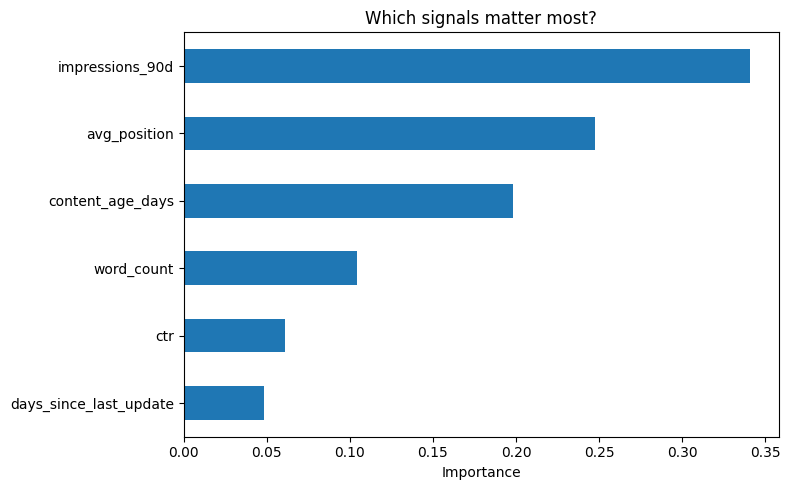

In [5]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", figsize=(8,5), title="Which signals matter most?")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

In [6]:
df["decline_risk_score"] = model.predict_proba(X)[:, 1]

def assign_action(row):
    if row["decline_risk_score"] >= 0.7 and row["impressions_90d"] >= 500:
        return "Improve — high risk, still visible, worth saving"
    elif row["decline_risk_score"] >= 0.7 and row["impressions_90d"] < 500:
        return "Monitor — high risk, low visibility, low priority"
    elif row["decline_risk_score"] < 0.3 and row["impressions_90d"] >= 1000:
        return "Protect — performing well, don't touch"
    elif row["days_since_last_update"] >= 365:
        return "Rewrite — very stale content"
    else:
        return "Monitor — no urgent action"

df["recommended_action"] = df.apply(assign_action, axis=1)
print(df["recommended_action"].value_counts())

action_plan = df[df["recommended_action"].str.startswith("Improve")].sort_values(
    "impressions_90d", ascending=False
)[["impressions_90d", "days_since_last_update", "avg_position", "ctr",
   "decline_risk_score", "recommended_action"]].head(15)
action_plan

recommended_action
Monitor — no urgent action                           29332
Improve — high risk, still visible, worth saving       274
Protect — performing well, don't touch                 239
Monitor — high risk, low visibility, low priority      150
Rewrite — very stale content                             5
Name: count, dtype: int64


,impressions_90d,days_since_last_update,avg_position,ctr,decline_risk_score,recommended_action
7860,26470,20,0.7,0.05,0.713433,"Improve — high risk, still visible, worth saving"
24369,12834,104,6.8,0.05,0.700473,"Improve — high risk, still visible, worth saving"
25146,8111,104,33.9,0.00,0.722186,"Improve — high risk, still visible, worth saving"
12930,8064,104,3.8,0.07,0.710745,"Improve — high risk, still visible, worth saving"
27115,5811,104,6.4,0.07,0.720272,"Improve — high risk, still visible, worth saving"
28459,5541,104,11.2,0.14,0.726992,"Improve — high risk, still visible, worth saving"
27888,5178,104,43.1,0.06,0.717056,"Improve — high risk, still visible, worth saving"
16488,4782,8,0.6,0.08,0.728947,"Improve — high risk, still visible, worth saving"
23811,4757,104,31.3,0.11,0.718475,"Improve — high risk, still visible, worth saving"
10451,4679,104,37.9,0.13,0.723418,"Improve — high risk, still visible, worth saving"


In [7]:
import os
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/scored_pages.csv", index=False)
action_plan.to_csv("outputs/top_action_plan.csv", index=False)
print("Saved!")

Saved!
